In [6]:
#############################################
"""
1. This file Generate the Dataset for training
"""

'\n1. This file Generate the Dataset for training\n'

In [7]:
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.LoRa import LoRa

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [ ]:
######## Parameters can be adjusted ######
fs = 1000000   # 1 MHz
bw = 125e3          # LoRa Bandwidth (125 kHz)
sf = 9       # Spreading Factor 

symbol_time = 2**sf / bw  # Symbol duration
N = 2**sf

lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
######## Parameters can be adjusted ######

In [9]:
# GENERATE NEW DATASET (ONCE)
GEENRATE_ = True
SNR_first = 15
SNR_last = -30

if (GEENRATE_):

    folder_path = f'dataset_sf{sf}_{input_row}x{input_col}'
    folder_ground_truth = f'clean_dataset_sf{sf}_{input_row}x{input_col}'

    # Check if folder exists, if not create it
    check_and_make_folder(folder_path)
    check_and_make_folder(folder_ground_truth)

    # Outer loop: from 15 to -30 (inclusive)
    for i in range(SNR_first, SNR_last, -1):  # step -1 to count down
        # Inner loop: 100 iteration

        for j in range(N): # 0 until 2**sf
            x1 = lora_init.gen_symbol_fs(j, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6
            snr = i
            x = lora_init.awgn_iq(x1,snr)
            #### DOWNSAMPLING
            create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,i,j,1,folder_path)

            if (i == SNR_first):
                clean_s = create_spectrogram_from_torch(x1,sf,bw,fs,input_row,input_col,999,j,0,None)
                np.save(f'{folder_ground_truth}/s_sf{sf}_bw125_{j}.npy',clean_s)
                
       

Folder already exists: dataset_sf9_512x33
Folder already exists: clean_dataset_sf9_512x33


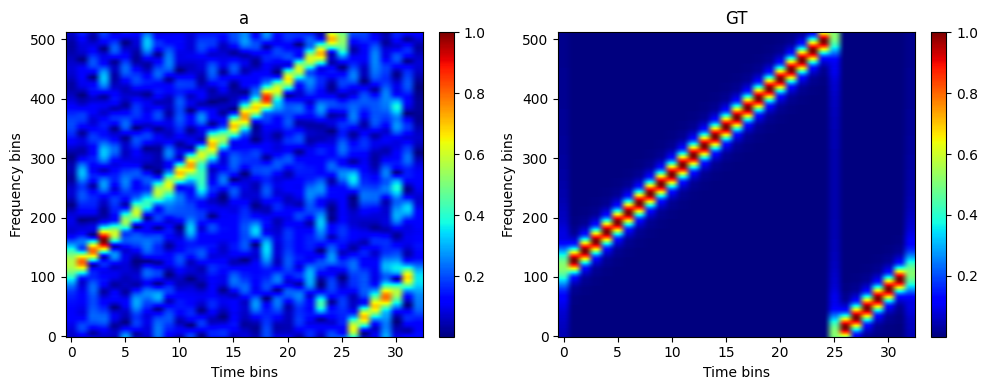

(512, 33)
float64
0.07432728910041901
1.066794206618748e-06
1.0


In [10]:
file_path = f"dataset_sf{sf}_{input_row}x{input_col}/s_sf{sf}_bw125_-10_112_1.npy"  # example path
data = np.load(file_path)
file_path2 = f"clean_dataset_sf{sf}_{input_row}x{input_col}/s_sf{sf}_bw125_112.npy"  # example path
data2 = np.load(file_path2)
show_multiple_spectrograms([data,data2],["a","GT"],2)
print(data2.shape)
print(data2.dtype)
print(data2.mean())
print(data2.min())
print(data2.max())